In [21]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('mlflow').setLevel(logging.ERROR)

In [28]:
#Baseline Prophet model
# MLflow experiment set karo
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('NeuralRetail_Demand_Forecasting')

# Data load karo
df_demand = pd.read_parquet(r'../data/features/demand_features.parquet')

# Prophet format chahiye: 'ds' (date) aur 'y' (value)
prophet_df = df_demand[['date', 'demand']].rename(
columns={'date': 'ds', 'demand': 'y'})
prophet_df['ds']= pd.to_datetime(prophet_df['ds'])

prophet_df = (prophet_df
              .set_index('ds')
              .resample('W')['y']
              .sum()
              .reset_index())

# Outliers cap kre
Q_low = prophet_df['y'].quantile(0.10)
Q_high = prophet_df['y'].quantile(0.90)
prophet_df['y']=prophet_df['y'].clip(Q_low,Q_high)

# Train/Test split — last 4 weeks test ke liye
train_df = prophet_df[:-4].copy()
test_df = prophet_df[-4:].copy()
print(f'Train:{len(train_df)} days|Test:{len(test_df)}weeks')

Train:96 days|Test:4weeks


15:53:48 - cmdstanpy - INFO - Chain [1] start processing
15:53:49 - cmdstanpy - INFO - Chain [1] done processing


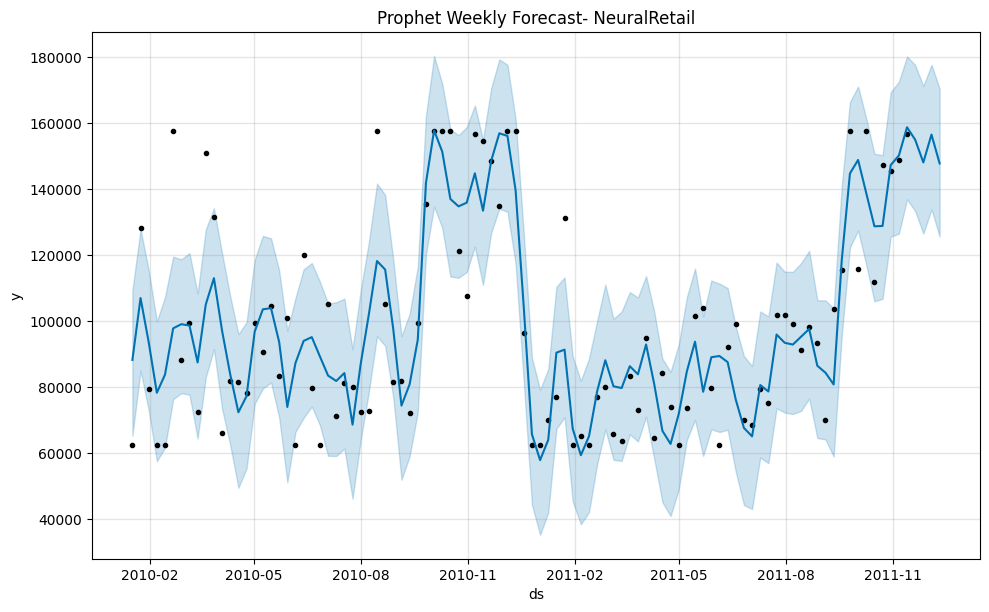

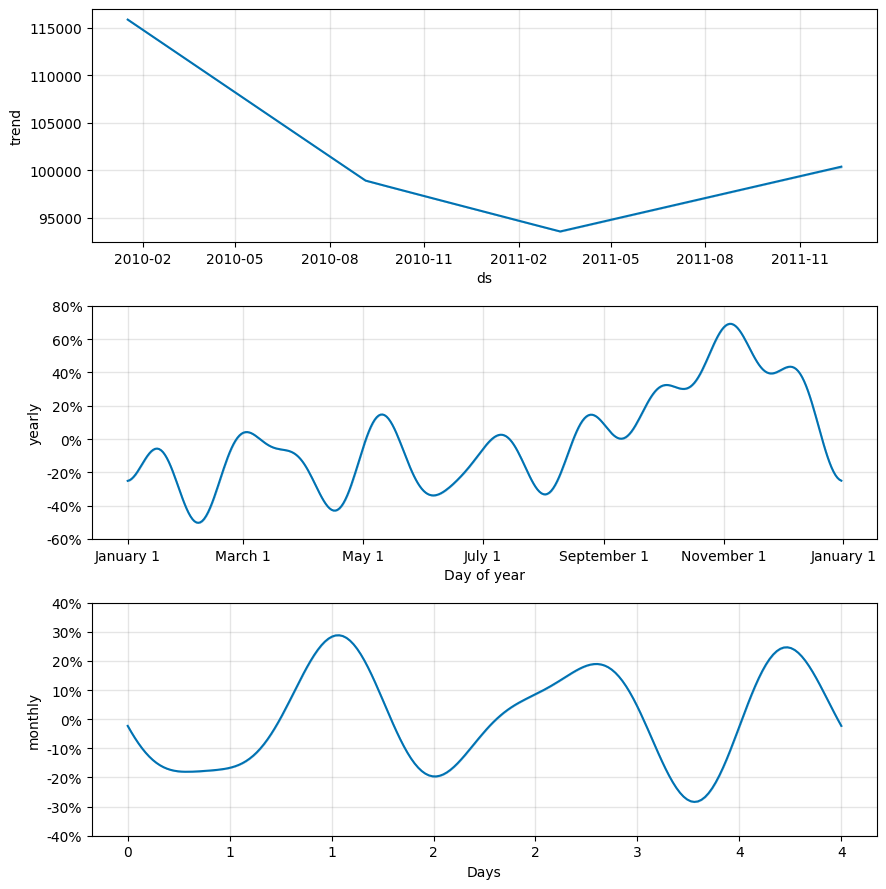

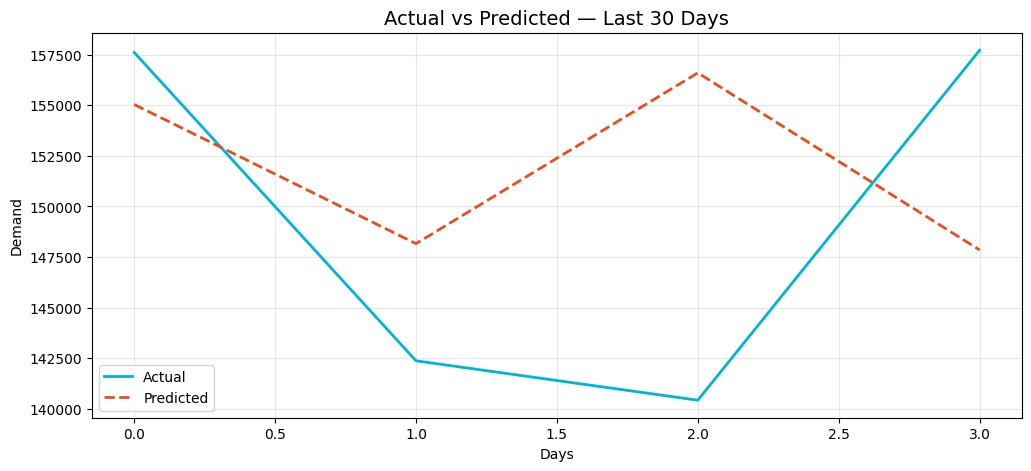

 Prophet Baseline Results
 MAPE : 5.87% (Target: <= 10%)
 RMSE : 9995
 MAE : 8606
Model registered in MLflow!
🏃 View run Prophet_Baseline at: http://localhost:5000/#/experiments/1/runs/c2aaad2411c6486dafa99b083ef67e67
🧪 View experiment at: http://localhost:5000/#/experiments/1


Registered model 'DemandForecast_Prophet' already exists. Creating a new version of this model...
Created version '3' of model 'DemandForecast_Prophet'.


In [29]:
# Mlflow run
mlflow.end_run()
with mlflow.start_run(run_name='Prophet_Baseline'):
    # Parameters log karo
    params = {
        'changepoint_prior_scale': 0.5,
        'seasonality_prior_scale': 20.0,
        'seasonality_mode': 'multiplicative',
        'yearly_seasonality': True,
        'weekly_seasonality': False, #(due to weekly data)
        'daily_seasonality': False,
    }
    mlflow.log_params(params)

    #create model
    model = Prophet(**params)
    
    # Add Monthlyseasonality 
    model.add_seasonality(
        name='monthly',
        period=4.3, #weekly data mein 4.3 weeks = 1 month
        fourier_order=5
    )
    #Model banao aur train karo
    model.fit(train_df)
   
    # future 4 weeks 
    future = model.make_future_dataframe(periods=4, freq='W')
    forecast = model.predict(future)
    
    # Test predictions
    test_pred = np.maximum(forecast.tail(4)['yhat'].values,0)
    test_actual = test_df['y'].values
   
    # Metrics calculate karo
    mape = mean_absolute_percentage_error(test_actual, test_pred) * 100
    rmse = np.sqrt(np.mean((test_actual - test_pred)**2))
    mae = np.mean(np.abs(test_actual - test_pred))
   
    # Metrics MLflow mein log karo
    mlflow.log_metric('MAPE',round(mape,2))
    mlflow.log_metric('RMSE',round(rmse,2))
    mlflow.log_metric('MAE',round(mae,2))
   
    # forcast plot
    fig1 = model.plot(forecast)
    plt.title('Prophet Weekly Forecast- NeuralRetail')
    fig.savefig(r'../reports/prophet_forecast.png', dpi=150, bbox_inches='tight')
    mlflow.log_artifact(r'../reports/prophet_forecast.png')
    plt.show()

    # components plot (trend + seasonality)
    fig2 = model.plot_components(forecast)
    fig2.savefig(r'../reports/prophet_components.png', dpi=150, bbox_inches='tight')
    mlflow.log_artifact(r'../reports/prophet_components.png')
    plt.show()
    
    # Plot Actual vs Predicted
    fig3, ax = plt.subplots(figsize=(12, 5))
    ax.plot(test_actual, label='Actual', color='#00B4D8', linewidth=2)
    ax.plot(test_pred, label='Predicted', color='#E84E1B', linewidth=2, linestyle='--')
    ax.set_title('Actual vs Predicted — Last 30 Days', fontsize=14)
    ax.set_xlabel('Days')
    ax.set_ylabel('Demand')
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig3.savefig(r'../reports/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
    mlflow.log_artifact(r'../reports/actual_vs_predicted.png')
    plt.show()

    # Results print karo
    print('=' * 40)
    print(' Prophet Baseline Results')
    print('=' * 40)
    print(f' MAPE : {mape:.2f}% (Target: <= 10%)')
    print(f' RMSE : {rmse:.0f}')
    print(f' MAE : {mae:.0f}')
    print('=' * 40)

    # Model MLflow mein register karo
    mlflow.prophet.log_model(
        model,
        artifact_path='prophet_model',
        registered_model_name='DemandForecast_Prophet'
    )
    print('Model registered in MLflow!')
